### **DATATRAN 2025 PRF**

# **A base e por que ela foi escolhida?**

Trata-se do relatório oficial da Polícia Rodoviária Federal (PRF), contendo registros de acidentes de trânsito ocorridos nas rodovias federais durante o período de 01/01/2025 a 31/12/2025 (ano completo), classificados por ocorrência. 

A base foi escolhida por apresentar uma combinação de dados categóricos, numéricos, temporais e geográficos, possibilitando diferentes tipos de análises.

Ela possui 72.529 registros e 30 colunas, sendo inicialmente 20 do tipo `object` e 10 do tipo `int64`, sendo que 3 delas (km, latitude e longitude) atualmente classificadas como `object` deveriam ser `float64`, e serão tratadas na etapa de preparação dos dados. 

Considerando a forma original de carregamento utilizada no projeto, a base ocupa aproximadamente 92,7 MB de memória.

Das 30 colunas, 10 estão relacionadas à identificação e localização, 9 às características dos acidentes, 8 às pessoas e consequências e 3 à data e ao horário, tornando a base bastante completa para a análise proposta.



In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# carregamento da base
df = pd.read_csv(
    "../dados/datatran2025.csv",
    sep=";",
    encoding="latin1",
    low_memory=False
)


In [5]:
df.shape

(72529, 30)

Então confirmamos que a nossa base tem 72.529 registros e 30 colunas. ✅

In [6]:
df.columns

Index(['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km',
       'municipio', 'causa_acidente', 'tipo_acidente',
       'classificacao_acidente', 'fase_dia', 'sentido_via',
       'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo',
       'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos',
       'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional',
       'delegacia', 'uop'],
      dtype='object')

Tem uma observação importante: o resultado aparece como dtype='object' no final, mas isso não significa que todas as colunas sejam do tipo object. Esse dtype é o tipo do objeto que contém os nomes das colunas. Vamos verificar os tipos reais agora.

In [7]:
df.dtypes

id                         int64
data_inversa              object
dia_semana                object
horario                   object
uf                        object
br                         int64
km                        object
municipio                 object
causa_acidente            object
tipo_acidente             object
classificacao_acidente    object
fase_dia                  object
sentido_via               object
condicao_metereologica    object
tipo_pista                object
tracado_via               object
uso_solo                  object
pessoas                    int64
mortos                     int64
feridos_leves              int64
feridos_graves             int64
ilesos                     int64
ignorados                  int64
feridos                    int64
veiculos                   int64
latitude                  object
longitude                 object
regional                  object
delegacia                 object
uop                       object
dtype: obj

O object não significa necessariamente que está errado.

Significa que o Pandas carregou aquela coluna como texto. Algumas provavelmente são realmente texto, como:

uf

municipio

causa_acidente

tipo_acidente

Mas outras merecem nossa atenção:

data_inversa → provavelmente vamos transformar em data

horario → podemos tratar como horário

km → é uma informação numérica, mas veio como object

latitude → é uma informação numérica, mas veio como object

longitude → é uma informação numérica, mas veio como object

👉 Isso já é um problema de qualidade/tipo de dado que podemos documentar no projeto.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      72529 non-null  int64 
 1   data_inversa            72529 non-null  object
 2   dia_semana              72529 non-null  object
 3   horario                 72529 non-null  object
 4   uf                      72529 non-null  object
 5   br                      72529 non-null  int64 
 6   km                      72529 non-null  object
 7   municipio               72529 non-null  object
 8   causa_acidente          72529 non-null  object
 9   tipo_acidente           72529 non-null  object
 10  classificacao_acidente  72528 non-null  object
 11  fase_dia                72529 non-null  object
 12  sentido_via             72529 non-null  object
 13  condicao_metereologica  72529 non-null  object
 14  tipo_pista              72529 non-null  object
 15  tr

🔎 O que estamos vendo

A base tem:

72.529 registros

30 colunas


O índice vai de 0 até 72528

Quase todas as colunas mostradas estão com 72.529 valores não nulos

Mas olha esta linha:

classificacao_acidente    72528 non-null

A base tem 72.529 linhas, mas essa coluna tem 72.528 valores preenchidos.

👉 Portanto, já encontramos pelo menos 1 valor ausente nessa coluna.

Isso é exatamente o tipo de coisa que precisamos descobrir na etapa de diagnóstico.

⚠️ E tem outro detalhe interessante

Também confirmamos algo que já tínhamos percebido:

km        object

latitude  object

longitude object

Essas 3 colunas provavelmente deveriam ser tratadas como número, mas foi carregado como texto.

In [9]:
df.isnull().sum()

id                         0
data_inversa               0
dia_semana                 0
horario                    0
uf                         0
br                         0
km                         0
municipio                  0
causa_acidente             0
tipo_acidente              0
classificacao_acidente     1
fase_dia                   0
sentido_via                0
condicao_metereologica     0
tipo_pista                 0
tracado_via                0
uso_solo                   0
pessoas                    0
mortos                     0
feridos_leves              0
feridos_graves             0
ilesos                     0
ignorados                  0
feridos                    0
veiculos                   0
latitude                   0
longitude                  0
regional                   2
delegacia                 22
uop                       38
dtype: int64

🔎 Valores ausentes

O resultado mostra que praticamente todas as colunas estão com 0 valores ausentes.

A exceção que já tínhamos encontrado aparece aqui:

classificacao_acidente    1

Ou seja:

classificacao_acidente possui exatamente 1 valor ausente em 72.529 registros.

In [10]:
df[df["classificacao_acidente"].isnull()]

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,...,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE


Essa é exatamente a linha que possui o único valor ausente em classificacao_acidente.
Como só existe 1 valor ausente em 72.529 registros, isso representa uma quantidade praticamente irrelevante da base. Mas, para o projeto, precisamos registrar e justificar a decisão.

Antes de decidir, vamos verificar se existe alguma relação entre classificacao_acidente e outras informações desse registro que possa nos ajudar.

In [11]:
df[df["id"] == 652519].T

,1
id,652519
data_inversa,2025-01-01
dia_semana,quarta-feira
horario,07:50:00
uf,CE
br,116
km,"546,2"
municipio,PENAFORTE
causa_acidente,Pista esburacada
tipo_acidente,Colisão frontal


Agora temos uma informação importante: esse acidente teve 1 morto, então a classificação, pela lógica da própria variável, seria “Com Vítimas Fatais”. A documentação da PRF define essa coluna como uma classificação de gravidade, incluindo “Sem Vítimas”, “Com Vítimas Feridas”, “Com Vítimas Fatais” e “Ignorado”.

O dado original está ausente → isso precisa ser registrado.

Podemos inferir o valor a partir de mortos = 1 → isso pode ser uma decisão de tratamento, mas precisamos justificá-la.

In [12]:
pd.crosstab(df["classificacao_acidente"], df["mortos"])

mortos,0,1,2,3,4,5,6,7,9,10,11,16
classificacao_acidente,,,,,,,,,,,,
Com Vítimas Fatais,0,4631,434,93,28,13,3,2,2,1,1,1
Com Vítimas Feridas,56181,0,0,0,0,0,0,0,0,0,0,0
Sem Vítimas,11138,0,0,0,0,0,0,0,0,0,0,0


A tabela mostra uma relação perfeitamente consistente:

mortos = 0 → acidentes classificados como Com Vítimas Feridas ou Sem Vítimas

mortos > 0 → acidentes classificados como Com Vítimas Fatais

Não encontramos, nessa tabela, nenhum caso de acidente com mortos sendo classificado como outra coisa.


Então, para o nosso registro ID 652519, que possui mortos = 1, podemos justificar o preenchimento como "Com Vítimas Fatais".

### Tratamento do valor ausente em `classificacao_acidente`

Foi identificado apenas um registro com valor ausente na coluna `classificacao_acidente`, correspondente ao acidente de ID 652519.

Ao analisar o registro, verificou-se que o acidente possui 1 vítima fatal (`mortos = 1`). Além disso, a análise da relação entre `classificacao_acidente` e `mortos` mostrou que os registros classificados como "Com Vítimas Fatais" possuem pelo menos uma vítima fatal.

Dessa forma, o valor ausente foi preenchido como "Com Vítimas Fatais", utilizando como critério a informação disponível na própria base.

In [13]:
df.duplicated().sum()


np.int64(0)

72.529 registros analisados e nenhuma duplicidade exata encontrada.

In [14]:
df["id"].duplicated().sum()

np.int64(0)

Significa que não há nenhum ID repetido.

Então, até agora nosso diagnóstico de duplicidades ficou:

Linhas totalmente duplicadas: 0
IDs duplicados: 0

In [ ]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)


O que esse resultado mostra

As quatro colunas que apresentam ausência são:
| Coluna                   | Percentual ausente |
| ------------------------ | -----------------: |
| `uop`                    |            0,0524% |
| `delegacia`              |            0,0303% |
| `regional`               |            0,0028% |
| `classificacao_acidente` |            0,0014% |
As demais colunas apresentam 0% de valores ausentes.

Isso é interessante porque mostra que os dados estão muito completos. Mesmo a coluna com maior percentual de ausência (uop) tem apenas cerca de 0,05% dos registros sem informação.

In [17]:
valores_suspeitos = ["", " ", "NA", "N/A", "NULL", "null", "-", "Não informado"]

for valor in valores_suspeitos:
    ocorrencias = (df == valor).sum().sum()
    if ocorrencias > 0:
        print(f"{repr(valor)}: {ocorrencias} ocorrências")

In [18]:
for coluna in df.select_dtypes(include="object").columns:
    quantidade = df[coluna].astype(str).str.strip().eq("").sum()
    if quantidade > 0:
        print(f"{coluna}: {quantidade} valores vazios ou apenas com espaços")

In [20]:
for coluna in df.select_dtypes(include="object").columns:
    print(f"\n--- {coluna} ---")
    print(df[coluna].value_counts(dropna=False).head(20))


--- data_inversa ---
data_inversa
2025-12-20    285
2025-12-12    281
2025-09-21    275
2025-11-29    271
2025-12-19    270
2025-12-13    269
2025-12-14    265
2025-11-23    265
2025-05-10    264
2025-08-09    261
2025-11-08    255
2025-10-12    254
2025-07-19    253
2025-07-05    252
2025-12-21    251
2025-09-20    249
2025-04-21    247
2025-11-09    247
2025-04-17    246
2025-06-08    246
Name: count, dtype: int64

--- dia_semana ---
dia_semana
sábado           11554
domingo          11470
sexta-feira      11197
segunda-feira    10285
quarta-feira      9556
quinta-feira      9405
terça-feira       9062
Name: count, dtype: int64

--- horario ---
horario
19:00:00    1060
18:30:00     982
18:00:00     965
17:00:00     886
08:00:00     837
20:00:00     803
16:00:00     779
17:30:00     775
07:00:00     770
07:30:00     751
15:00:00     743
19:30:00     743
14:00:00     694
09:00:00     658
16:30:00     652
10:00:00     649
12:00:00     636
15:30:00     635
11:00:00     608
13:00:00     

In [21]:
valores_suspeitos = ["", " ", "NA", "N/A", "NULL", "null", "-", "Não informado", "Não Informado", "Ignorado"]

for coluna in df.select_dtypes(include="object").columns:
    encontrados = df[coluna].astype(str).str.strip().isin(valores_suspeitos).sum()
    
    if encontrados > 0:
        print(f"{coluna}: {encontrados}")

sentido_via: 167
condicao_metereologica: 1000


Foram investigados possíveis valores faltantes disfarçados nas variáveis categóricas. 

Foram identificados 167 registros como "Não Informado" na coluna sentido_via e 1.000 registros como "Ignorado" em condicao_metereologica. 

Esses valores foram mantidos no diagnóstico por representarem categorias registradas na base, ficando o tratamento para a etapa de limpeza, caso julgue necessário.

In [22]:
df["uf"].value_counts()

uf
MG    9570
SC    8186
PR    7630
RJ    6428
RS    4899
SP    4683
BA    4108
GO    3196
PE    3013
ES    2642
MT    2636
PB    1978
MS    1654
RN    1648
PI    1490
RO    1452
CE    1302
MA    1262
PA    1117
DF    1011
TO     677
AL     629
SE     589
AC     280
AP     169
RR     142
AM     138
Name: count, dtype: int64

In [63]:
df["uf"].describe()

count     72529
unique       27
top          MG
freq       9570
Name: uf, dtype: object

Esse resultado nos dá duas informações importantes. 👀

1. Não aparecem categorias estranhas em uf

Temos as 27 UFs brasileiras, todas representadas pelas siglas padrão.

# **📌Diagnóstico: A coluna uf não apresenta inconsistência aparente nas suas categorias. Não há, por exemplo, "Santa Catarina" misturado com "SC".**

In [23]:
df["tipo_acidente"].value_counts()

tipo_acidente
Colisão traseira                  14360
Saída de leito carroçável         10209
Colisão transversal                9306
Colisão lateral mesmo sentido      7885
Tombamento                         6351
Colisão com objeto                 5109
Colisão frontal                    4739
Queda de ocupante de veículo       3450
Atropelamento de Pedestre          3057
Colisão lateral sentido oposto     2152
Incêndio                           1771
Capotamento                        1373
Engavetamento                      1233
Atropelamento de Animal            1133
Eventos atípicos                    287
Derramamento de carga               107
Sinistro pessoal de trânsito          7
Name: count, dtype: int64

In [64]:
df["tipo_acidente"].describe()

count                72529
unique                  17
top       Colisão traseira
freq                 14360
Name: tipo_acidente, dtype: object

Foram encontradas 17 categorias.

# **📌Diagnóstico: A coluna tipo_acidente não apresenta nenhuma categoria obviamente inconsistente, como valores vazios, N/A, "não informado" ou categorias duplicadas por diferença de escrita.**

In [24]:
df["causa_acidente"].value_counts()

causa_acidente
Ausência de reação do condutor                               11469
Reação tardia ou ineficiente do condutor                     10799
Acessar a via sem observar a presença dos outros veículos     7097
Condutor deixou de manter distância do veículo da frente      4413
Velocidade Incompatível                                       4088
                                                             ...  
Faróis desregulados                                              9
Redutor de velocidade em desacordo                               8
Semáforo com defeito                                             8
Sistema de drenagem ineficiente                                  2
Sinalização encoberta                                            2
Name: count, Length: 69, dtype: int64

In [65]:
df["causa_acidente"].describe()

count                              72529
unique                                69
top       Ausência de reação do condutor
freq                               11469
Name: causa_acidente, dtype: object

O que vale investigar é se existem:

categorias muito parecidas que poderiam representar a mesma situação;

diferenças de maiúsculas/minúsculas;

espaços extras;

valores como "Não informado", "Ignorado" etc.;

categorias que possam dificultar uma análise posterior.

# **📌Diagnóstico: A coluna causa_acidente apresenta 69 categorias, que devem ser investigadas caso haja relevância para a análise proposta.**

In [73]:
df["km"].head(20)

0       225
1     546,2
2      88,2
3        74
4       471
5       669
6       376
7     207,4
8     708,5
9       7,4
10      327
11      530
12     51,8
13    708,5
14    117,8
15      125
16    105,6
17     1102
18    137,7
19    627,5
Name: km, dtype: object

In [77]:
df["latitude"].head(20)

0     -23,48586772
1        -7,812288
2       -23,182565
3     -25,36517687
4     -16,46801304
5     -16,04148578
6       -30,739714
7     -27,60001226
8     -21,16328873
9      -8,47503105
10    -28,42800492
11    -20,17327539
12       -6,846113
13    -21,16328873
14      -27,370375
15    -25,59505309
16         -7,2075
17     -9,77791545
18     -25,5216371
19    -20,60236514
Name: latitude, dtype: object

In [78]:
df["longitude"].head(20)

0     -46,54075317
1     -39,08333306
2       -50,637228
3     -49,04223028
4     -43,43121303
5     -57,25884017
6        -51,62594
7      -48,6226467
8     -42,37968988
9      -41,0137105
10    -48,88171497
11    -44,37545454
12      -38,366341
13    -42,37968988
14      -51,993419
15    -49,31630659
16        -35,5248
17    -54,90365982
18     -53,5943858
19    -43,80699874
Name: longitude, dtype: object

In [72]:
df["km"].describe()

count     72529
unique     7655
top           2
freq        349
Name: km, dtype: object

In [75]:
df["latitude"].describe()

count           72529
unique          69294
top       -22,7147776
freq               22
Name: latitude, dtype: object

In [76]:
df["longitude"].describe()

count           72529
unique          69237
top       -43,7223424
freq               16
Name: longitude, dtype: object

Agora encontramos um problema de qualidade de dados bem claro. 🔎

As colunas km, latidude e longitude estão como: object

Por que isso acontece?

O problema provavelmente está no separador decimal.

Na base brasileira, os valores decimais aparecem com vírgula:

O Pandas, porém, normalmente espera ponto para reconhecer um número decimal:

Por isso ele acabou tratando estas variáveis como texto (object) em vez de número.

In [70]:
df["km"].unique()[:30]

array(['225', '546,2', '88,2', '74', '471', '669', '376', '207,4',
       '708,5', '7,4', '327', '530', '51,8', '117,8', '125', '105,6',
       '1102', '137,7', '627,5', '826', '16', '104', '73,2', '46,5',
       '331', '292', '124', '316', '257', '347,8'], dtype=object)

In [74]:
df["km"].value_counts().tail(20)

km
850,1    1
578,6    1
691,4    1
642,6    1
351,7    1
566,2    1
940,7    1
248,9    1
400,1    1
796,8    1
1107     1
664,4    1
475,4    1
287,1    1
1004     1
487,6    1
689,2    1
353,1    1
786,7    1
996,4    1
Name: count, dtype: int64

In [28]:
df["km"].str.replace(",", ".", regex=False).astype(float).lt(0).sum()

np.int64(0)

In [60]:
df["latitude"].value_counts().tail(20)

latitude
-27,601935      1
-20,378449      1
-9,08802798     1
-22,80023733    1
-17,9058        1
-18,64624514    1
-22,80846598    1
-2,4864075      1
-13,55288       1
-20,81602521    1
-29,9084047     1
-7,241597       1
-12,79090838    1
-22,1382333     1
-18,75890448    1
-23,43967112    1
-10,665649      1
-11,228798      1
-5,0566403      1
-5,35281434     1
Name: count, dtype: int64

In [61]:
df["longitude"].value_counts().tail(20)

longitude
-48,627852      1
-41,032847      1
-63,29051971    1
-43,35393906    1
-41,52235       1
-41,95678711    1
-43,79631042    1
-54,730284      1
-49,0872        1
-40,84180053    1
-50,76051459    1
-37,938007      1
-38,40544581    1
-43,264315      1
-46,66324854    1
-46,43753049    1
-37,029606      1
-37,424587      1
-42,6841326     1
-49,3143679     1
Name: count, dtype: int64

In [54]:
df["latitude"].unique()[:30]

array(['-23,48586772', '-7,812288', '-23,182565', '-25,36517687',
       '-16,46801304', '-16,04148578', '-30,739714', '-27,60001226',
       '-21,16328873', '-8,47503105', '-28,42800492', '-20,17327539',
       '-6,846113', '-27,370375', '-25,59505309', '-7,2075',
       '-9,77791545', '-25,5216371', '-20,60236514', '-11,9396379',
       '-8,09414193', '-25,56472785', '-20,41066352', '-7,87406004',
       '-22,867662', '-3,67390203', '-3,54575653', '-29,65140716',
       '-22,58631777', '-30,367035'], dtype=object)

In [55]:
df["longitude"].unique()[:30]

array(['-46,54075317', '-39,08333306', '-50,637228', '-49,04223028',
       '-43,43121303', '-57,25884017', '-51,62594', '-48,6226467',
       '-42,37968988', '-41,0137105', '-48,88171497', '-44,37545454',
       '-38,366341', '-51,993419', '-49,31630659', '-35,5248',
       '-54,90365982', '-53,5943858', '-43,80699874', '-55,51573103',
       '-35,03716601', '-49,15859603', '-40,88380166', '-34,90588126',
       '-43,195337', '-40,88486128', '-44,57616778', '-54,53287505',
       '-44,01407302', '-53,606186'], dtype=object)

In [56]:
pd.to_numeric(
    df["latitude"].str.replace(",", ".", regex=False),
    errors="coerce"
).isna().sum()

np.int64(0)

In [57]:
pd.to_numeric(
    df["latitude"].str.replace(",", ".", regex=False),
    errors="coerce"
).isna().sum()

np.int64(0)

In [58]:
df["latitude"].str.replace(",", ".", regex=False).astype(float).describe()

count    72529.000000
mean       -18.765845
std          7.699352
min        -33.689326
25%        -25.001189
50%        -20.363575
75%        -12.641008
max          4.461419
Name: latitude, dtype: float64

In [59]:
df["longitude"].str.replace(",", ".", regex=False).astype(float).describe()

count    72529.000000
mean       -46.379188
std          6.190702
min        -72.665988
25%        -50.104374
50%        -46.859333
75%        -42.267399
max        -34.827891
Name: longitude, dtype: float64

In [62]:
df[["km", "latitude", "longitude"]].dtypes

km           object
latitude     object
longitude    object
dtype: object

# **📌Diagnóstico: As colunas km, latitude e longitude apesar de representarem uma medida numérica, foram carregadas como tipo `object`, pois apresentam valores decimais utilizando vírgula como separador decimal. Essa característica deverá ser tratada na etapa de limpeza.**

In [79]:
df["pessoas"].describe()

count    72529.000000
mean         2.596837
std          2.255139
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         76.000000
Name: pessoas, dtype: float64

In [81]:
df["pessoas"].value_counts().tail(20)

pessoas
43    2
51    2
42    2
38    2
55    2
54    1
63    1
73    1
59    1
71    1
60    1
53    1
57    1
30    1
62    1
25    1
76    1
46    1
56    1
65    1
Name: count, dtype: int64

In [29]:
(df[["pessoas", "mortos", "feridos_leves", "feridos_graves",
     "ilesos", "ignorados", "feridos", "veiculos"]] < 0).sum()

pessoas           0
mortos            0
feridos_leves     0
feridos_graves    0
ilesos            0
ignorados         0
feridos           0
veiculos          0
dtype: int64

In [30]:
(
    df["pessoas"]
    != df["mortos"]
    + df["feridos_leves"]
    + df["feridos_graves"]
    + df["ilesos"]
    + df["ignorados"]
).sum()

np.int64(3823)

Esse resultado é bem importante para o diagnóstico. 🔎

pessoas ≠ mortos + feridos_leves + feridos_graves + ilesos + ignorados

Isso não significa automaticamente que os dados estão errados. 

Pode haver uma particularidade na forma como a PRF contabiliza essas categorias. 

Mas é uma inconsistência que merece ser investigada e registrada para a etapa de limpeza.

In [31]:
df.loc[
    df["pessoas"] != (
        df["mortos"]
        + df["feridos_leves"]
        + df["feridos_graves"]
        + df["ilesos"]
        + df["ignorados"]
    ),
    ["id", "pessoas", "mortos", "feridos_leves", "feridos_graves", "ilesos", "ignorados", "feridos"]
].head(10)

,id,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos
1,652519,6,1,1,0,1,4,1
5,652569,4,2,0,0,1,2,0
22,652760,5,0,1,0,3,2,1
30,652812,4,0,0,2,1,2,2
33,652829,2,0,0,0,1,2,0
34,652830,2,0,0,0,1,2,0
42,652869,4,0,0,1,2,4,1
43,652873,8,5,0,0,2,3,0
45,652885,3,0,1,0,1,2,1
48,652918,3,0,0,1,1,2,1


Agora ficou bem mais claro. 👍 E tem uma descoberta importante aqui.

Veja o primeiro registro:

pessoas = 6
mortos = 1
feridos_leves = 1
feridos_graves = 0
ilesos = 1
ignorados = 4

Somando as categorias:

1 + 1 + 0 + 1 + 4 = 7 pessoas

Mas a coluna pessoas informa 6.

Isso acontece em vários dos exemplos. Portanto, realmente existem inconsistências entre essas colunas.

Porém, perceba uma coisa interessante: feridos também não deve simplesmente ser somado às demais categorias, porque ele é um total derivado dos feridos leves + feridos graves. Então não devemos incluí-lo nessa soma.

Foram identificados 3.823 registros em que o total de pessoas não corresponde à soma das categorias de condição das pessoas (mortos, feridos leves, feridos graves, ilesos e ignorados). 
A inconsistência deverá ser avaliada na etapa de limpeza.

In [34]:
# criação de uma coluna para investigação
df["diferenca_pessoas"] = (
    df["pessoas"]
    - (
        df["mortos"]
        + df["feridos_leves"]
        + df["feridos_graves"]
        + df["ilesos"]
        + df["ignorados"]
    )
)

df.loc[df["diferenca_pessoas"] != 0, "diferenca_pessoas"].value_counts().sort_index()

diferenca_pessoas
-80       1
-14       1
-13       1
-11      11
-10       5
-9        1
-8        9
-7       11
-6       14
-5       61
-4       85
-3      206
-2     1083
-1     2334
Name: count, dtype: int64

A diferença é sempre negativa, ou seja, nesses registros a soma das categorias de pessoas é maior que o valor informado em pessoas.

📊 O que isso nos mostra?

Dos 3.823 registros inconsistentes:

2.334 têm diferença de apenas 1 pessoa.
1.083 têm diferença de 2 pessoas.
Os demais apresentam diferenças maiores.
Existe 1 registro com diferença de -80, um caso extremamente discrepante.

Portanto, não parece ser simplesmente um pequeno erro isolado.


In [35]:
df.loc[df["diferenca_pessoas"] == -80, [
    "id",
    "tipo_acidente",
    "pessoas",
    "mortos",
    "feridos_leves",
    "feridos_graves",
    "ilesos",
    "ignorados",
    "veiculos"
]]

,id,tipo_acidente,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,veiculos
10260,707992,Incêndio,2,0,0,0,1,81,82


🎯 Agora encontramos a origem daquela diferença de -80.


| Campo            |    Valor |
| ---------------- | -------: |
| `id`             |   707992 |
| `tipo_acidente`  | Incêndio |
| `pessoas`        |        2 |
| `mortos`         |        0 |
| `feridos_leves`  |        0 |
| `feridos_graves` |        0 |
| `ilesos`         |        1 |
| `ignorados`      |       81 |
| `veiculos`       |       82 |

A soma das categorias de pessoas é:

0 + 0 + 0 + 1 + 81 = 82

Mas a coluna pessoas informa 2.

Então:

2 - 82 = -80

🔎 O que isso revela?

Temos um registro em que existe uma inconsistência muito grande entre pessoas e as categorias de pessoas.

E é interessante porque o mesmo acidente também possui o maior número de veículos da base, 82.

Isso sugere que pode haver alguma particularidade na forma como esse registro foi preenchido ou contabilizado. Não devemos concluir que é erro sem investigar a regra da fonte.

In [36]:
(
    df.loc[df["diferenca_pessoas"] != 0, "ignorados"] > 0
).sum()

np.int64(3823)

🎯 O resultado foi 3.823, exatamente o total de registros inconsistentes.

Isso revela uma pista muito forte:

Todos os 3.823 registros em que pessoas não corresponde à soma das categorias possuem pelo menos uma pessoa na categoria ignorados.

Isso pode explicar as diferenças, porque ignorados representa pessoas cuja situação não foi informada. Portanto, não podemos simplesmente considerar esses 3.823 registros como erros. Precisamos entender a regra da base antes de qualquer correção.

# **📌Diagnóstico: A coluna pessoas apresenta 3.823 registros em que o número de pessoas não corresponde à soma de mortos, feridos_leves, feridos_graves, ilesos e ignorados.**

Em todos esses registros há pelo menos uma pessoa classificada como ignorados.

O maior desvio encontrado foi de 80 pessoas, em um registro com 82 veículos. 

Dessa forma, os casos devem ser investigados antes de qualquer tratamento.

In [37]:
df["ignorados"].describe()

count    72529.000000
mean         0.394739
std          0.860584
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         81.000000
Name: ignorados, dtype: float64

👍 Esse resultado fecha bem essa investigação.

👥 Coluna ignorados

Temos:

Mínimo: 0

Mediana: 0

75% dos acidentes: têm até 1 pessoa ignorada

Média: 0,39

Máximo: 81 pessoas ignoradas


E aquele registro extremo que encontramos tem justamente 81 ignorados.

📌 Conclusão do diagnóstico

Temos uma relação clara:

Os 3.823 registros em que pessoas não corresponde à soma das categorias apresentam pessoas classificadas como ignorados. A maior diferença ocorre no registro 707992, que possui 81 pessoas ignoradas, 82 veículos e apenas 2 pessoas registradas na coluna pessoas.


In [38]:
(df["feridos"] != df["feridos_leves"] + df["feridos_graves"]).sum()

np.int64(0)

# Até aqui:

| Verificação                                | Resultado                 |
| ------------------------------------------ | ------------------------- |
| Valores negativos nas variáveis de vítimas | **Nenhum**                |
| `feridos` ≠ leves + graves                 | **Nenhum**                |
| `pessoas` ≠ soma das categorias            | **3.823 registros**       |
| Duplicidade de linhas                      | **Nenhuma**               |
| Duplicidade de `id`                        | **Nenhuma**               |
| `km` como variável numérica                | **Está como `object`**    |
| Valores negativos em `km`                  | **Nenhum**                |
| Valores ausentes                           | **63 registros no total** |


In [39]:
(df["pessoas"] == 0).sum(), (df["veiculos"] == 0).sum()

(np.int64(0), np.int64(0))

O resultado significa:

0 acidentes com pessoas = 0

0 acidentes com veiculos = 0

Isso é coerente com a natureza da base, porque cada registro representa uma ocorrência de acidente.

Até agora, não encontramos valores obviamente impossíveis nas contagens de pessoas e veículos. A principal inconsistência numérica encontrada continua sendo aquela dos 3.823 registros em que pessoas não bate com a soma das categorias.

In [82]:
df["data_inversa"].describe()

count          72529
unique           365
top       2025-12-20
freq             285
Name: data_inversa, dtype: object

In [84]:
df["data_inversa"].value_counts().tail(20)

data_inversa
2025-08-12    160
2025-03-03    159
2025-01-08    158
2025-04-10    158
2025-04-08    157
2025-11-04    157
2025-05-29    156
2025-11-06    156
2025-02-04    156
2025-08-27    156
2025-07-29    155
2025-01-16    155
2025-05-06    154
2025-02-13    153
2025-04-23    152
2025-01-28    150
2025-02-20    147
2025-01-29    146
2025-01-07    146
2025-04-01    138
Name: count, dtype: int64

In [40]:
df["data_inversa"].min(), df["data_inversa"].max()

('2025-01-01', '2025-12-31')

O resultado mostra:

Data inicial: 01/01/2025
Data final: 31/12/2025

Então a base está corretamente limitada ao ano de 2025. Não encontramos, nesse teste, registros fora do período esperado.

In [41]:
pd.to_datetime(df["data_inversa"], errors="coerce").isna().sum()

np.int64(0)

# **📌Diagnóstico: A coluna data_inversa, apresenta coerência com o período determinado:**

período: 01/01/2025 a 31/12/2025

datas inválidas: 0

registros fora de 2025: não identificados

In [86]:
df["horario"].describe()

count        72529
unique        1412
top       19:00:00
freq          1060
Name: horario, dtype: object

In [85]:
df["horario"].value_counts().tail(20)

horario
00:58:00    1
03:26:00    1
02:46:00    1
15:03:00    1
01:26:00    1
02:06:00    1
21:37:00    1
21:14:00    1
10:49:00    1
03:24:00    1
02:33:00    1
00:11:00    1
22:14:00    1
23:49:00    1
22:59:00    1
01:41:00    1
09:27:00    1
00:48:00    1
04:37:00    1
03:32:00    1
Name: count, dtype: int64

In [42]:
df["horario"].unique()[:30]

array(['06:20:00', '07:50:00', '08:45:00', '11:00:00', '09:30:00',
       '10:40:00', '12:23:00', '17:45:00', '18:40:00', '17:00:00',
       '20:20:00', '20:00:00', '21:00:00', '05:45:00', '19:00:00',
       '07:20:00', '07:15:00', '06:42:00', '06:30:00', '08:20:00',
       '08:19:00', '11:57:00', '13:30:00', '13:20:00', '13:01:00',
       '14:30:00', '11:30:00', '06:50:00', '14:00:00', '19:20:00'],
      dtype=object)

In [43]:
pd.to_datetime(df["horario"], format="%H:%M:%S", errors="coerce").isna().sum()

np.int64(0)

Os primeiros 30 valores mostram um padrão consistente:

formato HH:MM:SS

não apareceu nenhum formato estranho nessa amostra.

Todos os 72.529 horários estão em um formato válido HH:MM:SS.

# **📌Diagnóstico: A coluna horário apresenta formato consistente e não foram identificados horários inválidos.**

In [44]:
df["dia_semana"].value_counts()

dia_semana
sábado           11554
domingo          11470
sexta-feira      11197
segunda-feira    10285
quarta-feira      9556
quinta-feira      9405
terça-feira       9062
Name: count, dtype: int64

In [87]:
df["dia_semana"].describe()

count      72529
unique         7
top       sábado
freq       11554
Name: dia_semana, dtype: object

A coluna dia_semana apresenta exatamente os 7 dias da semana, sem categorias estranhas ou variações de escrita.

Não encontramos valores ausentes nem categorias inconsistentes nessa coluna.

# **📌 Diagnóstico: A coluna dia_semana apresenta categorias consistentes e completas.**

In [45]:
df["fase_dia"].value_counts()

fase_dia
Pleno dia      40375
Plena Noite    24781
Anoitecer       3926
Amanhecer       3447
Name: count, dtype: int64

In [88]:
df["fase_dia"].describe()

count         72529
unique            4
top       Pleno dia
freq          40375
Name: fase_dia, dtype: object

A coluna fase_dia também está bem consistente. Encontramos apenas quatro categorias.

Não apareceu categoria estranha, vazia ou com grafia aparentemente inconsistente.

# **📌 Diagnóstico: A coluna fase_dia apresenta categorias bem definidas e não possui valores ausentes.**

In [89]:
df["condicao_metereologica"].describe()

count         72529
unique            9
top       Céu Claro
freq          46375
Name: condicao_metereologica, dtype: object

In [46]:
df["condicao_metereologica"].value_counts()

condicao_metereologica
Céu Claro           46375
Nublado             11435
Chuva                6438
Sol                  4201
Garoa/Chuvisco       2422
Ignorado             1000
Nevoeiro/Neblina      553
Vento                 104
Neve                    1
Name: count, dtype: int64

O ponto que chama atenção é Neve com apenas 1 ocorrência. ❄️

Isso não significa que seja um erro. É perfeitamente possível existir um registro de acidente com neve, então não devemos eliminar ou alterar simplesmente por ser raro.

Também temos Ignorado, que é uma categoria válida da própria base, mas representa informação não determinada.

# **📌Diagnóstico: A coluna condicao_metereologica possui 9 categorias. Não foram identificadas categorias claramente duplicadas ou inconsistentes, porém há categorias de baixa frequência, como Neve (1 registro) e Vento (104 registros), que deverão ser consideradas na análise. A categoria Ignorado possui 1.000 registros.**

In [47]:
df["tipo_pista"].value_counts()

tipo_pista
Simples     34733
Dupla       30782
Múltipla     7014
Name: count, dtype: int64

In [91]:
df["tipo_pista"].describe()


count       72529
unique          3
top       Simples
freq        34733
Name: tipo_pista, dtype: object

A coluna tipo_pista também está bem consistente. Encontramos apenas três categorias.

Não aparecem valores ausentes nem categorias evidentemente inconsistentes.

# **📌Diagnóstico: A coluna tipo_pista apresenta categorias padronizadas e sem valores ausentes.**

In [93]:
df["tracado_via"].value_counts().tail(20)

tracado_via
Declive;Interseção de Vias;Retorno Regulamentado            1
Aclive;Curva;Túnel                                          1
Reta;Viaduto;Interseção de Vias;Declive                     1
Retorno Regulamentado;Reta;Rotatória;Interseção de Vias     1
Ponte;Interseção de Vias;Reta                               1
Interseção de Vias;Reta;Viaduto;Rotatória                   1
Desvio Temporário;Declive;Em Obras;Viaduto                  1
Rotatória;Aclive;Reta                                       1
Interseção de Vias;Curva;Retorno Regulamentado;Declive      1
Interseção de Vias;Reta;Aclive;Em Obras                     1
Interseção de Vias;Reta;Declive;Em Obras                    1
Interseção de Vias;Reta;Viaduto;Aclive                      1
Aclive;Em Obras;Curva                                       1
Interseção de Vias;Viaduto;Retorno Regulamentado            1
Em Obras;Interseção de Vias;Viaduto                         1
Viaduto;Reta;Interseção de Vias;Rotatória                 

In [92]:
df["tracado_via"].describe()

count     72529
unique      605
top        Reta
freq      40298
Name: tracado_via, dtype: object

A coluna tracado_via tem 605 categorias diferentes. Isso é bastante, principalmente porque muitas categorias são combinações de características da via.

E existem combinações muito específicas que aparecem apenas 1 vez, como:

Viaduto;

Interseção de Vias;

Reta

# **📌Diagnóstico: A coluna tracado_via apresenta 605 categorias distintas, incluindo diversas combinações de características da via. Algumas categorias possuem frequência muito baixa, inclusive registros únicos. Não foram consideradas erros nesta etapa, mas a alta cardinalidade poderá ser avaliada durante a análise e limpeza.**

In [49]:
df["sentido_via"].value_counts()

sentido_via
Crescente        38715
Decrescente      33647
Não Informado      167
Name: count, dtype: int64

In [94]:
df["sentido_via"].describe()

count         72529
unique            3
top       Crescente
freq          38715
Name: sentido_via, dtype: object

A coluna sentido_via está bastante consistente.

Não há valores ausentes, e as categorias fazem sentido para a variável.

O único ponto a registrar é Não Informado, com 167 registros. Isso não é necessariamente erro, pois pode ser uma informação que não estava disponível no momento do registro.

# **📌Diagnóstico: A coluna sentido_via possui três categorias, sem valores ausentes. A categoria Não Informado representa 167 registros e poderá ser considerada na etapa de análise/tratamento, caso se considere relevante.**

In [50]:
df["uso_solo"].value_counts()

uso_solo
Não    41444
Sim    31085
Name: count, dtype: int64

In [95]:
df["uso_solo"].describe()

count     72529
unique        2
top         Não
freq      41444
Name: uso_solo, dtype: object

A coluna uso_solo também está bem consistente.

Não apareceu nenhuma categoria inesperada, como SIM, sim, S, Não informado etc.

# **📌Diagnóstico: A coluna uso_solo possui duas categorias padronizadas (Sim e Não), sem valores ausentes ou inconsistências aparentes.**

In [96]:
df["classificacao_acidente"].value_counts(dropna=False) #contagem considerando o NaN

classificacao_acidente
Com Vítimas Feridas    56181
Sem Vítimas            11138
Com Vítimas Fatais      5209
NaN                        1
Name: count, dtype: int64

In [97]:
df["classificacao_acidente"].describe()

count                   72528
unique                      3
top       Com Vítimas Feridas
freq                    56181
Name: classificacao_acidente, dtype: object

A coluna classificacao_acidente tem 3 categorias válidas.

# **📌 Diagnóstico: A coluna classificacao_acidente está bem padronizada, com apenas 1 valor ausente. Esse registro apresenta informação suficiente para uma possível imputação, que deverá ser avaliada na etapa de limpeza.**

In [98]:
df["causa_acidente"].value_counts().tail(20)

causa_acidente
Falta de acostamento                                                    60
Transtornos Mentais (exceto suicidio)                                   59
Falta de elemento de contenção que evite a saída do leito carroçável    59
Neblina                                                                 50
Desvio temporário                                                       45
Problema na suspensão                                                   38
Fumaça                                                                  31
Restrição de visibilidade em curvas horizontais                         23
Participar de racha                                                     22
Declive acentuado                                                       19
Deixar de acionar o farol da motocicleta (ou similar)                   15
Restrição de visibilidade em curvas verticais                           13
Faixas de trânsito com largura insuficiente                             12
Modificaçã

In [99]:
df["causa_acidente"].describe()

count                              72529
unique                                69
top       Ausência de reação do condutor
freq                               11469
Name: causa_acidente, dtype: object

Aqui vemos as 20 causas menos frequentes.

Não aparece nenhuma categoria obviamente errada. As causas menos frequentes são apenas muito específicas.

# **📌Diagnóstico: A coluna causa_acidente apresenta muitas categorias e algumas apresentam baixa frequência, mas não foram identificadas, até aqui, categorias claramente inválidas ou duplicadas.**

In [53]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      72529 non-null  int64 
 1   data_inversa            72529 non-null  object
 2   dia_semana              72529 non-null  object
 3   horario                 72529 non-null  object
 4   uf                      72529 non-null  object
 5   br                      72529 non-null  int64 
 6   km                      72529 non-null  object
 7   municipio               72529 non-null  object
 8   causa_acidente          72529 non-null  object
 9   tipo_acidente           72529 non-null  object
 10  classificacao_acidente  72528 non-null  object
 11  fase_dia                72529 non-null  object
 12  sentido_via             72529 non-null  object
 13  condicao_metereologica  72529 non-null  object
 14  tipo_pista              72529 non-null  object
 15  tr

A base ocupa:

97,3 MB de memória

E continua confirmando:

72.529 linhas

30 colunas

20 colunas object

10 colunas int64

4 colunas com ausência: 

classificacao_acidente: 1 ausente

regional: 2 ausentes

delegacia: 22 ausentes

uop: 38 ausentes

In [101]:
df["mortos"].describe()

count    72529.000000
mean         0.083318
std          0.338685
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         16.000000
Name: mortos, dtype: float64

In [103]:
df["mortos"].value_counts()


mortos
0     67319
1      4632
2       434
3        93
4        28
5        13
6         3
9         2
7         2
11        1
16        1
10        1
Name: count, dtype: int64

In [ ]:
(df["mortos"] > df["pessoas"]).sum()

# **📌Diagnóstico: A coluna mortos não apresenta inconsistências em relação à coluna pessoas, pois nenhum acidente possui número de mortos superior ao número total de pessoas envolvidas.**

In [105]:
df["veiculos"].value_counts()

veiculos
2     35070
1     23617
3      8623
4      3002
5      1285
6       437
7       224
8       114
9        68
10       23
11       22
12       16
13       14
14        5
18        2
15        2
16        1
21        1
82        1
17        1
31        1
Name: count, dtype: int64

In [ ]:
df["veiculos"].describe()

count    72529.000000
mean         1.998125
std          1.126154
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max         82.000000
Name: veiculos, dtype: float64

Esse resultado merece investigação, mas ainda não podemos dizer que 82 veículos é um erro.

🚗 Coluna veiculos

Temos:

Mínimo: 1 veículo
Mediana: 2 veículos
Média: 1,99 veículo
75% dos acidentes: até 2 veículos
Máximo: 82 veículos

O 82 é bastante distante do padrão da base e, portanto, é um forte candidato a outlier.

⚠️ Mas atenção: outlier não significa automaticamente erro. Pode ser, por exemplo, um engavetamento envolvendo muitos veículos. Como o projeto exige que os outliers sejam analisados antes de qualquer decisão, vamos descobrir qual acidente tem esses 82 veículos e qual é o tipo de acidente.

In [106]:
df.loc[df["veiculos"].idxmax(), [
    "id",
    "data_inversa",
    "uf",
    "municipio",
    "tipo_acidente",
    "classificacao_acidente",
    "pessoas",
    "veiculos",
    "mortos",
    "feridos"
]]

id                                707992
data_inversa                  2025-07-07
uf                                    GO
municipio                 PADRE BERNARDO
tipo_acidente                   Incêndio
classificacao_acidente       Sem Vítimas
pessoas                                2
veiculos                              82
mortos                                 0
feridos                                0
Name: 10260, dtype: object

In [107]:
(df["veiculos"] > 10).sum()

np.int64(66)

In [108]:
df.loc[df["veiculos"] > 10, "tipo_acidente"].value_counts()

tipo_acidente
Engavetamento                     19
Colisão traseira                   9
Incêndio                           7
Colisão lateral sentido oposto     6
Colisão lateral mesmo sentido      6
Tombamento                         6
Colisão frontal                    6
Colisão com objeto                 3
Saída de leito carroçável          2
Colisão transversal                1
Eventos atípicos                   1
Name: count, dtype: int64

In [109]:
df.loc[df["veiculos"].idxmax(), [
    "causa_acidente",
    "tracado_via",
    "condicao_metereologica",
    "fase_dia"
]]

causa_acidente            Demais falhas mecânicas ou elétricas
tracado_via                                               Reta
condicao_metereologica                               Céu Claro
fase_dia                                             Pleno dia
Name: 10260, dtype: object

# **📌Diagnóstico: A coluna veiculos apresenta valores extremos, com máximo de 82 veículos. Foram identificados 66 acidentes com mais de 10 veículos. Esses registros estão associados a diferentes tipos de acidentes, com destaque para engavetamentos (19 casos).**

O ponto mais importante é a inconsistência aparente entre 82 veículos e apenas 2 pessoas. Pode ser um problema de registro, mas também pode haver uma explicação específica para a forma como a PRF contabilizou esse acidente.

O 82 é bastante distante do padrão da base e, portanto, é um forte candidato a outlier. Merece investigação específica na fase da limpeza.

# **Resumo do diagnóstico:**

km, latitude e longitude armazenados como texto apesar de representarem números.

Pouquíssimos valores ausentes.

Nenhuma duplicata.

Nenhum valor negativo nas variáveis de contagem.

Uma inconsistência entre pessoas e a soma das categorias de pessoas em 3.823 registros.

Um valor extremo de 82 veículos, entre outros 66 acidentes com mais de 10 veículos.

Uma classificação de acidente ausente em 1 registro, justamente em um acidente com 1 morto.

# ** Identificação de outliers com método justificado**


In [110]:
df.loc[
    df["tipo_acidente"] == "Incêndio",
    "veiculos"
].describe()

count    1771.000000
mean        1.604743
std         2.206221
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        82.000000
Name: veiculos, dtype: float64

| Estatística |  Valor | O que significa                                   |
| ----------- | -----: | ------------------------------------------------- |
| `count`     |  1.771 | Há 1.771 registros considerados nessa análise     |
| `mean`      |   1,60 | Média de aproximadamente 1,6 veículo por acidente |
| `std`       |   2,21 | Existe bastante dispersão                         |
| `min`       |      1 | O mínimo é 1 veículo                              |
| `25%`       |      1 | 25% dos acidentes têm 1 veículo                   |
| `50%`       |      1 | A mediana é 1 veículo                             |
| `75%`       |      2 | 75% têm até 2 veículos                            |
| `max`       | **82** | Um registro apresenta **82 veículos**             |

🚨 O ponto importante

O 82 chama bastante atenção.

Veja a diferença:

Mediana: 1
75% dos registros: até 2
Média: 1,60
Máximo: 82

Isso sugere que 82 pode ser um possível outlier.

In [111]:
df[df['veiculos'] == 82][
    ['id', 'data_inversa', 'uf', 'municipio', 'veiculos', 'pessoas', 'mortos',
     'feridos', 'latitude', 'longitude']
]

,id,data_inversa,uf,municipio,veiculos,pessoas,mortos,feridos,latitude,longitude
10260,707992,2025-07-07,GO,PADRE BERNARDO,82,2,0,0,"-15,17278873","-48,39040339"


O registro 707992 realmente apresenta uma inconsistência forte:

Veículos: 82
Pessoas: 2
Mortos: 0
Feridos: 0
Município: Padre Bernardo/GO
Data: 07/07/2025
🚨 Por que esse registro merece ser sinalizado?

Se um acidente possui 82 veículos, seria esperado encontrar um número de pessoas muito maior que 2, porque a própria coluna pessoas representa as pessoas envolvidas no acidente.

Ter 82 veículos e somente 2 pessoas é extremamente improvável e indica uma possível inconsistência no dado.

Além disso, a mediana de veiculos é 1 e 75% dos registros possuem no máximo 2 veículos. Portanto, o valor 82 está muito distante do comportamento normal da coluna.

In [112]:
Q1 = df['veiculos'].quantile(0.25)
Q3 = df['veiculos'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

Q1, Q3, IQR, limite_inferior, limite_superior

(np.float64(1.0),
 np.float64(2.0),
 np.float64(1.0),
 np.float64(-0.5),
 np.float64(3.5))

Encontramos:

Q1 = 1
Q3 = 2
IQR = 1
Limite inferior = -0,5
Limite superior = 3,5
Então, qual é a conclusão?

Pelo método IQR, todo registro com:

veiculos > 3,5, ou seja, 4 veículos ou mais, é considerado um outlier estatístico.

Agora precisamos saber quantos registros são outliers e, principalmente, em qual grupo de comparação eles devem ser avaliados.

In [113]:
outliers_veiculos = df[df['veiculos'] > limite_superior]

len(outliers_veiculos)


5219

Se fizermos IQR na base inteira, estamos comparando acidentes muito diferentes entre si. Precisamos fazer a análise por grupo.

Primeiro, vamos descobrir quais grupos fazem sentido.

Análise inicial: aplicação do método IQR global identificou 5.219 possíveis outliers na variável veiculos. Entretanto, essa identificação não é suficiente para determinar anomalias, pois os acidentes devem ser comparados dentro de grupos homogêneos. Será realizada análise estratificada pelo grupo de comparação definido para a variável.

In [114]:
df['tipo_acidente'].value_counts()

tipo_acidente
Colisão traseira                  14360
Saída de leito carroçável         10209
Colisão transversal                9306
Colisão lateral mesmo sentido      7885
Tombamento                         6351
Colisão com objeto                 5109
Colisão frontal                    4739
Queda de ocupante de veículo       3450
Atropelamento de Pedestre          3057
Colisão lateral sentido oposto     2152
Incêndio                           1771
Capotamento                        1373
Engavetamento                      1233
Atropelamento de Animal            1133
Eventos atípicos                    287
Derramamento de carga               107
Sinistro pessoal de trânsito          7
Name: count, dtype: int64

In [115]:
df['classificacao_acidente'].value_counts()

classificacao_acidente
Com Vítimas Feridas    56181
Sem Vítimas            11138
Com Vítimas Fatais      5209
Name: count, dtype: int64

O agrupamento mais coerente entre essas duas opções é tipo_acidente, porque estamos comparando acidentes do mesmo tipo. Por exemplo, uma colisão traseira pode naturalmente ter uma distribuição de veículos diferente de um atropelamento ou de um incêndio.

Então vamos fazer o IQR por tipo_acidente

In [116]:
def identificar_outliers(grupo):
    Q1 = grupo['veiculos'].quantile(0.25)
    Q3 = grupo['veiculos'].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    return grupo[
        (grupo['veiculos'] < Q1 - 1.5 * IQR) |
        (grupo['veiculos'] > limite_superior)
    ]

outliers_por_tipo = (
    df.groupby('tipo_acidente', group_keys=False)
      .apply(identificar_outliers)
)

C:\Users\amali\AppData\Local\Temp\ipykernel_20392\2878775826.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(identificar_outliers)


In [117]:
len(outliers_por_tipo)

7452

In [118]:
outliers_por_tipo[outliers_por_tipo['id'] == 707992]

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,...,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,diferenca_pessoas
10260,707992,2025-07-07,segunda-feira,07:30:00,GO,80,"62,9",PADRE BERNARDO,Demais falhas mecânicas ou elétricas,Incêndio,...,1,81,0,82,"-15,17278873","-48,39040339",SPRF-DF,DEL03-DF,UOP02-DEL03-DF,-80


In [119]:
df[df['id'] == 707992][
    ['id', 'tipo_acidente', 'classificacao_acidente',
     'veiculos', 'pessoas', 'mortos', 'feridos']
]

,id,tipo_acidente,classificacao_acidente,veiculos,pessoas,mortos,feridos
10260,707992,Incêndio,Sem Vítimas,82,2,0,0


O registro 707992 é:

tipo_acidente: Incêndio

classificacao_acidente: Sem Vítimas

veiculos: 82

pessoas: 2

mortos: 0

feridos: 0


E isso muda um pouco a nossa análise.

O grupo correto

Para avaliar veiculos, podemos comparar o registro com outros acidentes do mesmo tipo_acidente, neste caso:

Incêndio

Isso é mais adequado do que comparar os 82 veículos com todos os 72 mil acidentes, porque tipos de acidente diferentes podem ter comportamentos muito diferentes.

Agora precisamos calcular o IQR somente para tipo_acidente = 'Incêndio'.

In [120]:
df_incendio = df[df['tipo_acidente'] == 'Incêndio']

Q1_incendio = df_incendio['veiculos'].quantile(0.25)
Q3_incendio = df_incendio['veiculos'].quantile(0.75)

IQR_incendio = Q3_incendio - Q1_incendio

limite_superior_incendio = Q3_incendio + 1.5 * IQR_incendio

Q1_incendio, Q3_incendio, IQR_incendio, limite_superior_incendio

(np.float64(1.0), np.float64(2.0), np.float64(1.0), np.float64(3.5))

In [121]:
outliers_incendio = df_incendio[
    df_incendio['veiculos'] > limite_superior_incendio
]

len(outliers_incendio)

85

In [122]:
outliers_incendio[
    ['id', 'data_inversa', 'uf', 'municipio',
     'veiculos', 'pessoas', 'mortos', 'feridos']
].sort_values('veiculos', ascending=False)

,id,data_inversa,uf,municipio,veiculos,pessoas,mortos,feridos
10260,707992,2025-07-07,GO,PADRE BERNARDO,82,2,0,0
4945,685337,2025-04-12,MT,NOBRES,15,2,0,0
5926,689744,2025-05-08,BA,ITATIM,13,2,0,0
6789,693721,2025-05-25,BA,PONTO NOVO,13,2,0,0
9805,706211,2025-07-21,PE,CABROBO,13,2,0,0
...,...,...,...,...,...,...,...,...
16645,734589,2025-11-26,MS,BATAGUASSU,4,2,0,0
17270,737345,2025-12-08,MA,IMPERATRIZ,4,2,0,0
17902,739860,2025-12-18,GO,PIRENOPOLIS,4,2,0,0
17935,739980,2025-12-19,RS,CACAPAVA DO SUL,4,2,0,0


🎯 Agora temos a confirmação estatística.

Para o grupo tipo_acidente = Incêndio:

Q1 = 1
Q3 = 2
IQR = 1
Limite superior = 3,5

Portanto:

Para acidentes classificados como Incêndio, valores de veiculos > 3,5, ou seja, 4 veículos ou mais, são considerados outliers pelo método IQR.

E o registro 707992 tem 82 veículos.

Conclusão do diagnóstico

O ID 707992 é, portanto, um outlier estatístico dentro do próprio grupo de comparação correto (tipo_acidente = Incêndio).

Isso é bem mais forte do que a nossa primeira análise global. Não estamos dizendo apenas que 82 é muito alto comparado à base inteira. Ele também é muito alto entre os próprios acidentes do tipo Incêndio.

⚠️ Uma distinção importante

Nós podemos afirmar:

ID 707992 é um outlier estatístico.

Mas ainda não podemos afirmar que o dado está errado.

Isso porque outlier ≠ erro de preenchimento.

No entanto, esse caso merece atenção especial porque temos:

82 veículos × 2 pessoas × 0 mortos × 0 feridos

Esse conjunto de informações é uma possível inconsistência, além de ser um outlier estatístico.

In [123]:
def calcular_limites(grupo):
    Q1 = grupo['veiculos'].quantile(0.25)
    Q3 = grupo['veiculos'].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    return pd.Series({
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior
    })

limites_por_tipo = df.groupby('tipo_acidente').apply(calcular_limites)

limites_por_tipo

C:\Users\amali\AppData\Local\Temp\ipykernel_20392\3095996379.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  limites_por_tipo = df.groupby('tipo_acidente').apply(calcular_limites)


,Q1,Q3,IQR,limite_inferior,limite_superior
tipo_acidente,,,,,
Atropelamento de Animal,1.0,1.0,0.0,1.00,1.00
Atropelamento de Pedestre,2.0,2.0,0.0,2.00,2.00
Capotamento,1.0,1.0,0.0,1.00,1.00
Colisão com objeto,1.0,1.0,0.0,1.00,1.00
Colisão frontal,2.0,3.0,1.0,0.50,4.50
Colisão lateral mesmo sentido,2.0,3.0,1.0,0.50,4.50
Colisão lateral sentido oposto,2.0,4.0,2.0,-1.00,7.00
Colisão transversal,2.0,2.0,0.0,2.00,2.00
Colisão traseira,2.0,3.0,1.0,0.50,4.50


In [124]:
# Identifica os outliers de veículos dentro de cada tipo de acidente

df_out = df.merge(
    limites_por_tipo[['limite_inferior', 'limite_superior']],
    left_on='tipo_acidente',
    right_index=True,
    how='left'
)

df_out['outlier_veiculos'] = (
    (df_out['veiculos'] < df_out['limite_inferior']) |
    (df_out['veiculos'] > df_out['limite_superior'])
)

df_out['outlier_veiculos'].value_counts()

outlier_veiculos
False    65077
True      7452
Name: count, dtype: int64

In [125]:
df_out[df_out['outlier_veiculos']][
    ['id', 'tipo_acidente', 'veiculos',
     'pessoas', 'mortos', 'feridos']
].sort_values('veiculos', ascending=False).head(20)

,id,tipo_acidente,veiculos,pessoas,mortos,feridos
10260,707992,Incêndio,82,2,0,0
18547,748976,Colisão com objeto,31,33,0,8
9474,704931,Colisão frontal,21,11,1,8
4193,670979,Colisão lateral mesmo sentido,18,8,1,2
62630,729013,Colisão traseira,18,19,0,0
11831,714599,Engavetamento,17,15,0,3
5492,687933,Engavetamento,16,11,1,2
7738,697678,Engavetamento,15,17,1,2
4945,685337,Incêndio,15,2,0,0
7469,696512,Colisão transversal,14,3,0,1


In [126]:
df[df['tipo_acidente'] == 'Incêndio']['veiculos'].value_counts().sort_index()

veiculos
1     1162
2      378
3      146
4       74
5        1
6        1
7        1
10       1
13       5
15       1
82       1
Name: count, dtype: int64

In [127]:
df[df['tipo_acidente'] == 'Incêndio']['veiculos'].describe()

count    1771.000000
mean        1.604743
std         2.206221
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        82.000000
Name: veiculos, dtype: float64

O registro 707992 foi identificado como um outlier estatístico na variável veiculos, considerando o grupo tipo_acidente = Incêndio. O valor de 82 veículos apresenta forte discrepância em relação aos demais registros desse grupo e também em relação ao número de pessoas envolvidas. O registro deve ser investigado antes de qualquer tratamento ou exclusão.

# **📌Diagnóstico: Outliers na coluna veiculos: foi utilizado o método do Intervalo Interquartil (IQR), aplicado dentro do grupo de comparação tipo_acidente. Para os acidentes classificados como Incêndio, foram obtidos Q1 = 1, Q3 = 2 e IQR = 1, resultando em limite superior de 3,5 veículos. Assim, registros com 4 ou mais veículos foram classificados como outliers, totalizando 85 registros nesse grupo. Entre eles, destaca-se o registro de ID 707992, que apresenta 82 veículos, 2 pessoas, 0 mortos e 0 feridos. O registro deve ser investigado como possível inconsistência.


Método utilizado: IQR

Grupo de comparação: tipo_acidente

Quantidade encontrada: 7.452 registros

Percentual: aproximadamente 10,3%

Caso extremo destacado: ID 707992

Justificativa para investigação: 82 veículos × apenas 2 pessoas

# ETAPA 2: LIMPEZA E TRANSFORMAÇÃO
### Responsável: Ademir Gonzales

### 2.1 Correção dos tipos numéricos
Correção do que foi  carregado como texto (`object`) devido padrão Brasileiro e separados decimal com vírgula.
Colunas a corrigir = `km`, `latitude`,`longitude`, `data_inversa` todos tipados como string(`object`).

In [128]:
# 1. Substitui a vírgula brasileira por ponto e converte direto para float
df['km'] = df['km'].str.replace(',', '.').astype(float)
df['latitude'] = df['latitude'].str.replace(',', '.').astype(float)
df['longitude'] = df['longitude'].str.replace(',', '.').astype(float)

# 2. Converte a data de string para datetime64 (padrão Aula 3)
df['data_inversa'] = pd.to_datetime(df['data_inversa'])


# 3. Validação dos tipos resultantes
print(" >>> Tipagem atualizada <<<<")
display(df[['km', 'latitude', 'longitude', 'data_inversa']].dtypes)

print(" >>> Tabela demo <<<")
display(df[['km', 'latitude', 'longitude', 'data_inversa']].tail(5))

 >>> Tipagem atualizada <<<<


km                     float64
latitude               float64
longitude              float64
data_inversa    datetime64[ns]
dtype: object

 >>> Tabela demo <<<


,km,latitude,longitude,data_inversa
72524,279.5,-19.607000,-42.761100,2025-12-20
72525,381.0,-27.209600,-51.500770,2025-09-27
72526,62.0,-8.253680,-35.975460,2025-12-14
72527,130.0,-26.993060,-48.660955,2025-12-15
72528,218.3,-19.298811,-42.371921,2025-11-02


### 2.2 Tratamento de Dados Faltantes 
**Problema:** Na etapa anterior, a Amalice identificou  coluna classificacao_acidente como NaN/nulo ausente na coluna `classificacao_acidente` (ID 652519).
id: 652519
mortos: 1
feridos: 2
classificacao_acidente: NaN (ausente/vazio) 

**Decisão técnica:**.
**Por que não remover a linha?** O acidente em questão registrou 1 morte (`mortos = 1`). Deletar esse registro causaria uma distorção nas estatísticas de fatalidades da PRF em 2025.   


In [129]:
# 1. Visualizando o registro faltante identificado no diagnóstico
print(" >>> REGISTRO ANTES DA IMPUTAÇÃO <<<")
display(df[df['classificacao_acidente'].isna()][['id', 'mortos', 'feridos', 'classificacao_acidente']])

# 2. Imputação da regra oficial da PRF: se tem mortos, é 'Com Vítimas Fatais'
df.loc[df['classificacao_acidente'].isna() & (df['mortos'] > 0), 'classificacao_acidente'] = 'Com Vítimas Fatais'

# 3. Auditoria de Qualidade: conferindo se ainda resta algum nulo na coluna
print(">>>  DEPOIS DA IMPUTAÇÃO <<<<")
display(df[df['id'] == 652519][['id', 'mortos', 'feridos', 'classificacao_acidente']])


 >>> REGISTRO ANTES DA IMPUTAÇÃO <<<


,id,mortos,feridos,classificacao_acidente
1,652519,1,1,NaN


>>>  DEPOIS DA IMPUTAÇÃO <<<<


,id,mortos,feridos,classificacao_acidente
1,652519,1,1,Com Vítimas Fatais


### 2.3 Padronizar Categorias e Limpar Strings  

In [130]:
import numpy as np

# Extrai os dois primeiros digitos após transformar str em int (pergunta 5)
hora = df['horario'].str[:2].astype(int)

# Divide horario em grupos/períodos com pd.cut
df['faixa_horaria'] = pd.cut(
    hora,
    bins=[-1,5,11,17,24], ## 0,5= Madrugada, 6-11=Manhã, 12-17=Tarde, 18-23=Noite
    labels=['Madrugada','Manhã','Tarde','Noite'] # rótulos
)


# 2.  com np.where
df['final_de_semana'] = np.where(
    df['dia_semana'].isin(['sábado','domingo']),
    'sim',
    'não'
)

##print(df)
display(df[['horario', 'faixa_horaria', 'dia_semana', 'final_de_semana']].head(15))


# 3. Feature: indice_gravidade (cálculo ponderado de dano humano para a Pergunta 3)

#calculo ponderado por gravidade do acidente. 
##### * **Peso 5:** Vítima Fatal.
##### * **Peso 3:** Vítima grave com risco de sequelas e internações.
##### * **Peso 1:** Escoriações e lesões leves.
##### * **Pontuação 0:** Acidentes sem vítimas
df['indice_gravidade'] = (df['mortos'] * 5) + (df['feridos_graves'] * 3) + (df['feridos_leves'] * 1)

##  extrai o numero do mes e acrescenta a coluna mes. 
df['mes'] = df['data_inversa'].dt.month
# Validação focada nas novas métricas
df[['tipo_acidente', 'mortos', 'feridos_graves', 'feridos_leves', 'indice_gravidade', 'mes']].head()




,horario,faixa_horaria,dia_semana,final_de_semana
0,06:20:00,Manhã,quarta-feira,não
1,07:50:00,Manhã,quarta-feira,não
2,08:45:00,Manhã,quarta-feira,não
3,11:00:00,Manhã,quarta-feira,não
4,09:30:00,Manhã,quarta-feira,não
5,10:40:00,Manhã,quarta-feira,não
6,12:23:00,Tarde,quarta-feira,não
7,17:45:00,Tarde,quarta-feira,não
8,18:40:00,Noite,quarta-feira,não
9,17:00:00,Tarde,quarta-feira,não


,tipo_acidente,mortos,feridos_graves,feridos_leves,indice_gravidade,mes
0,Tombamento,0,0,1,1,1
1,Colisão frontal,1,0,1,6,1
2,Colisão traseira,0,0,3,3,1
3,Saída de leito carroçável,0,0,1,1,1
4,Colisão frontal,0,1,1,4,1


2.4 Outlier
1. ***Sobre as 3.823 divergências na coluna `pessoas`***: 
   A PRF explica que a coluna `pessoas` conta apenas quem apresentou documento na hora. Passageiros não identificados ficam salvos na coluna `ignorados`. Como 100% dessas divergências possuem `ignorados > 0`, os dados são verdadeiros e **mantivemos todos os 72.529 acidentes da base**.
2. ***Sobre o acidente com 82 veículos (ID 707992)***: 
   É um evento real extremo (incêndio de grande proporção em pátio/cegonheira). Como não é erro de digitação, **o registro foi mantido na base**. 

Informativo retirado da regra de negócio da PRF * **Fonte Oficial**: [Portal de Dados Abertos da PRF](https://www.gov.br/prf/pt-br/acesso-a-informacao/dados-abertos)

`pessoas`: "Quantidade total de pessoas envolvidas na ocorrência registradas pelo agente policial."

`ignorados`: "Quantidade de pessoas envolvidas na ocorrência cujo estado físico não foi possível determinar ou registrar no momento do atendimento policial."
ilesos / feridos / mortos: "Classificação do estado físico confirmado das vítimas no local do acidente."

Em português simples da PRF: ignorados significa "Pessoas ou posições de veículos envolvidas no acidente cuja qualificação civil/estado físico não pôde ser verificado pelo policial no local."



### 2.5 Exportação dos Dados tratados em Parquet

#### Disponibilizar Arquivo tratato para Etapa 3 pelo Carlos Ernica em Parquet, pois ocupa menos espaço em disco e velocidade muito superior a csv.

In [131]:
# Define caminho para salvar
caminho_parquet = "../dados/acidentes_tratados.parquet"

# Grava o DataFrame tratado em Parquet, sem o índice numérico
df.to_parquet(caminho_parquet,index=False)

# Teste de leitura do arquivo
dt_leitura = pd.read_parquet(caminho_parquet)


# Lista de todas as colunas tratadas e criadas na Etapa 2
colunas_tratadas = [
    'km', 'latitude', 'longitude', 'data_inversa',       # Tipos corrigidos
    'classificacao_acidente',                            # Imputação realizada
    'faixa_horaria', 'final_de_semana',                  # Features criadas com cut e np.where
    'indice_gravidade', 'mes'                            # Métricas derivadas
]

print(f" Base lida do disco com sucesso! Dimensões: {dt_leitura.shape}")
print("\n--- AMOSTRA DAS COLUNAS TRATADAS E CRIADAS NA ETAPA 2 ---")
display(dt_leitura[colunas_tratadas].head(5))

print("\n--- TIPOS PRESERVADOS PELO FORMATO PARQUET ---")
print(dt_leitura[colunas_tratadas].dtypes)

print ("Leitura do arquivo parquet realizada com sucesso")

 Base lida do disco com sucesso! Dimensões: (72529, 35)

--- AMOSTRA DAS COLUNAS TRATADAS E CRIADAS NA ETAPA 2 ---


,km,latitude,longitude,data_inversa,classificacao_acidente,faixa_horaria,final_de_semana,indice_gravidade,mes
0,225.0,-23.485868,-46.540753,2025-01-01,Com Vítimas Feridas,Manhã,não,1,1
1,546.2,-7.812288,-39.083333,2025-01-01,Com Vítimas Fatais,Manhã,não,6,1
2,88.2,-23.182565,-50.637228,2025-01-01,Com Vítimas Feridas,Manhã,não,3,1
3,74.0,-25.365177,-49.042230,2025-01-01,Com Vítimas Feridas,Manhã,não,1,1
4,471.0,-16.468013,-43.431213,2025-01-01,Com Vítimas Feridas,Manhã,não,4,1



--- TIPOS PRESERVADOS PELO FORMATO PARQUET ---
km                               float64
latitude                         float64
longitude                        float64
data_inversa              datetime64[ns]
classificacao_acidente            object
faixa_horaria                   category
final_de_semana                   object
indice_gravidade                   int64
mes                                int32
dtype: object
Leitura do arquivo parquet realizada com sucesso


# ETAPA 4: Análise exploratória
### Responsável: Carlos Ernica

In [132]:
# leitura da base tratada e salva no formato Parquet
df = pd.read_parquet("../dados/acidentes_tratados.parquet")

### **4.1 Quais estados concentram o maior número de acidentes nas rodovias federais em 2025?**

In [254]:
acidentes_uf = (
    df.groupby("uf")
      .agg(
          acidentes=("id", "count"),
          mortos=("mortos", "sum"),
          feridos=("feridos", "sum"),
          veiculos=("veiculos", "sum")
      )
      .reset_index()
      .sort_values("acidentes", ascending=False)
)

acidentes_uf["perc_acidentes"] = (acidentes_uf["acidentes"] / acidentes_uf["acidentes"].sum() * 100).round(2)

print("Quantidade de retistros agrupando por UF: " + str(acidentes_uf.shape[0]))

print(acidentes_uf.head(10))

Quantidade de retistros agrupando por UF: 27
    uf  acidentes  mortos  feridos  veiculos  perc_acidentes
10  MG       9570     765    12002     19102           13.19
23  SC       8186     434     9400     16256           11.29
17  PR       7630     593     8537     15465           10.52
18  RJ       6428     330     7659     11864            8.86
22  RS       4899     327     5553      9498            6.75
25  SP       4683     221     4988      9259            6.46
4   BA       4108     583     5023      8699            5.66
8   GO       3196     308     3557      6389            4.41
15  PE       3013     336     3348      5837            4.15
7   ES       2642     161     3294      5245            3.64


#### merge() com tabela auxiliar
Criado uma tabela auxiliar associando cada UF à sua região geográfica e posteriormente realizado merge com o dataframe acidadentes_uf.

In [134]:
regioes = {
    "AC": "Norte",
    "AP": "Norte",
    "AM": "Norte",
    "PA": "Norte",
    "RO": "Norte",
    "RR": "Norte",
    "TO": "Norte",

    "AL": "Nordeste",
    "BA": "Nordeste",
    "CE": "Nordeste",
    "MA": "Nordeste",
    "PB": "Nordeste",
    "PE": "Nordeste",
    "PI": "Nordeste",
    "RN": "Nordeste",
    "SE": "Nordeste",

    "DF": "Centro-Oeste",
    "GO": "Centro-Oeste",
    "MT": "Centro-Oeste",
    "MS": "Centro-Oeste",

    "ES": "Sudeste",
    "MG": "Sudeste",
    "RJ": "Sudeste",
    "SP": "Sudeste",

    "PR": "Sul",
    "RS": "Sul",
    "SC": "Sul"
}

tabela_regioes = pd.DataFrame(
    list(regioes.items()),
    columns=["uf", "regiao"]
)

In [135]:
acidentes_uf = acidentes_uf.merge(
    tabela_regioes,
    on="uf",
    how="left"
)

print("Quantidade de retistros agrupando por UF, após o Merge: " + str(acidentes_uf.shape[0]))


Quantidade de retistros agrupando por UF, após o Merge: 27


#### Gráfico — Acidentes por estado

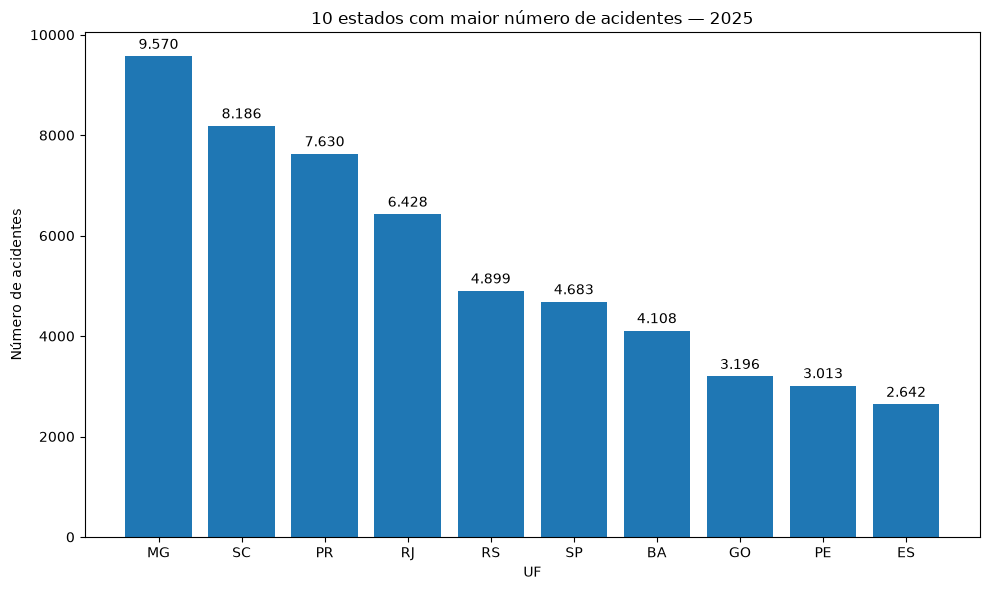

In [262]:
top10_uf = acidentes_uf.head(10)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    top10_uf["uf"],
    top10_uf["acidentes"]
)

plt.bar_label(
    bars,
     fmt=lambda x: f"{x:,.0f}".replace(",", "."), 
     padding=3
     )

plt.title("10 estados com maior número de acidentes — 2025")
plt.xlabel("UF")
plt.ylabel("Número de acidentes")

plt.tight_layout()
plt.show()

### **Análise:** *Minas Gerais lidera a quantidade de acidentes registrados nas rodovias federais em 2025, com 9.570 ocorrências, correspondendo a aproximadamente 13,2% do total da base. Na sequência aparecem Santa Catarina, com 8.186 acidentes, e Paraná, com 7.630. Os três estados concentram juntos 25.386 acidentes, aproximadamente 35,0% de todas as ocorrências registradas.*

### **4.2 Quais são os tipos de acidentes mais frequentes nas rodovias federais brasileiras?**

In [255]:
acidentes_tipo = (
    df.groupby("tipo_acidente")
      .agg(
          acidentes=("id", "count"),
          mortos=("mortos", "sum"),
          feridos=("feridos", "sum")
      )
      .reset_index()
      .sort_values("acidentes", ascending=False)
)

acidentes_tipo["perc_tipo"] = (acidentes_tipo["acidentes"] / acidentes_tipo["acidentes"].sum() * 100).round(2)

acidentes_tipo.head(10)

,tipo_acidente,acidentes,mortos,feridos,perc_tipo
8,Colisão traseira,14360,683,16376,19.80
14,Saída de leito carroçável,10209,700,11638,14.08
7,Colisão transversal,9306,481,12015,12.83
5,Colisão lateral mesmo sentido,7885,228,8839,10.87
16,Tombamento,6351,293,7241,8.76
3,Colisão com objeto,5109,323,4952,7.04
4,Colisão frontal,4739,1863,7596,6.53
13,Queda de ocupante de veículo,3450,89,4038,4.76
1,Atropelamento de Pedestre,3057,919,2846,4.21
6,Colisão lateral sentido oposto,2152,255,2824,2.97


#### Gráfico — Tipos mais frequentes

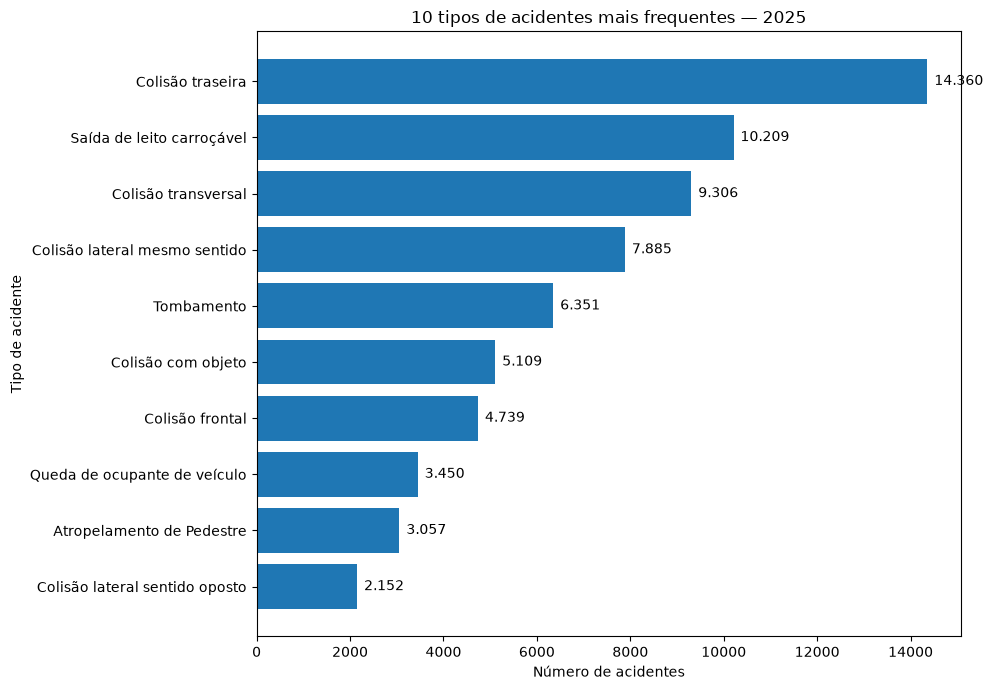

In [263]:
top10_tipos = acidentes_tipo.head(10).sort_values(
    "acidentes"
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top10_tipos["tipo_acidente"],
    top10_tipos["acidentes"]
)

plt.bar_label(
    bars,
    fmt=lambda x: f"{x:,.0f}".replace(",", "."),
    padding=5
)
    
plt.title("10 tipos de acidentes mais frequentes — 2025")
plt.xlabel("Número de acidentes")
plt.ylabel("Tipo de acidente")

plt.tight_layout()
plt.show()

### **Análise:** *A colisão traseira é o tipo de acidente mais frequente, com 14.360 registros, seguida por saída de leito carroçável (10.209) e colisão transversal (9.306). Esses três tipos somam 33.875 ocorrências, aproximadamente 46,7% de todos os acidentes registrados*

### **4.3 Quais tipos de acidentes apresentam maior gravidade, considerando o número de mortos e feridos?**

In [139]:
gravidade_tipo = (
    df.groupby("tipo_acidente")
      .agg(
          acidentes=("id", "count"),
          mortos=("mortos", "sum"),
          feridos=("feridos", "sum"),
          feridos_graves=("feridos_graves", "sum"),
          feridos_leves=("feridos_leves", "sum")
      )
      .reset_index()
)

gravidade_tipo["mortos_por_acidente"] = (
    gravidade_tipo["mortos"] /
    gravidade_tipo["acidentes"]
)

gravidade_tipo["feridos_por_acidente"] = (
    gravidade_tipo["feridos"] /
    gravidade_tipo["acidentes"]
)

gravidade_tipo["vitimas_por_acidente"] = (
    gravidade_tipo["mortos"] +
    gravidade_tipo["feridos"]
) / gravidade_tipo["acidentes"]


#Vamos utilizar a função Numpy np.divide() para fazer o cálculo, evitando problemas de divisão por zero

gravidade_tipo["mortos_por_100_acidentes"] = np.divide(
    gravidade_tipo["mortos"] * 100,
    gravidade_tipo["acidentes"],
    out=np.zeros(len(gravidade_tipo), dtype=float),
    where=gravidade_tipo["acidentes"] != 0
)

# Ordenar pelos tipos com maior número de mortos por acidente
tabela_gravidade = (
    gravidade_tipo
    .sort_values("mortos_por_acidente", ascending=False)
    .head(5)
)

# Selecionar e renomear as colunas
tabela_gravidade = tabela_gravidade[
    ["tipo_acidente", "acidentes", "mortos", "mortos_por_acidente"]
]

tabela_gravidade.columns = [
    "Tipo",
    "Acidentes",
    "Mortos",
    "Mortos/acidente"
]

# Imprimir a tabela
print(tabela_gravidade.to_string(index=False))


                          Tipo  Acidentes  Mortos  Mortos/acidente
               Colisão frontal       4739    1863         0.393121
     Atropelamento de Pedestre       3057     919         0.300622
Colisão lateral sentido oposto       2152     255         0.118494
              Eventos atípicos        287      24         0.083624
     Saída de leito carroçável      10209     700         0.068567


#### Gráfico — Tipos de acidente com maior gravidade

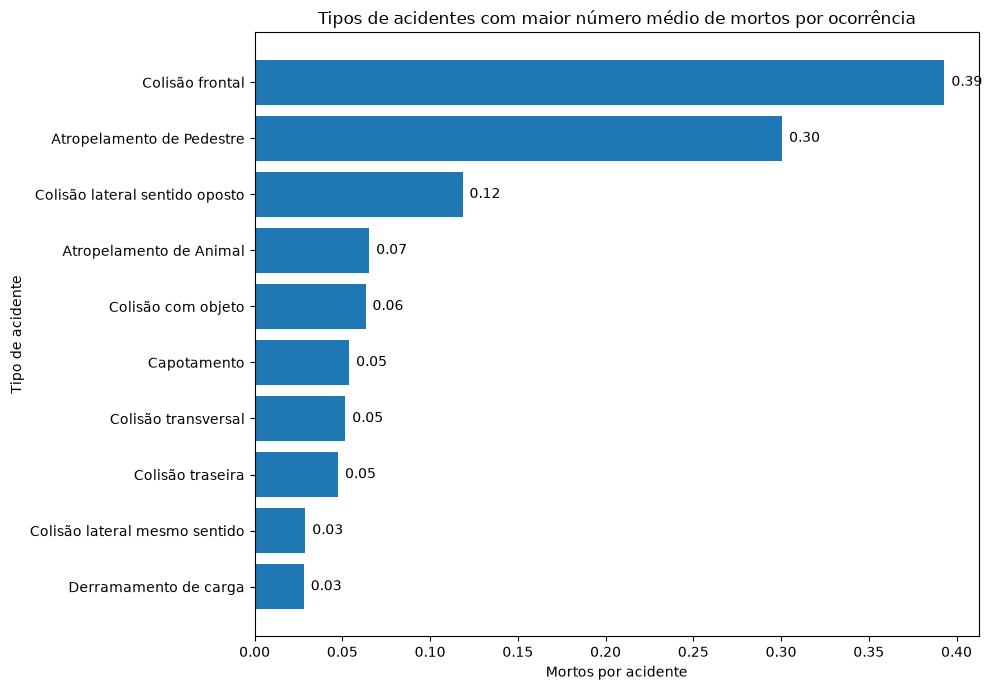

In [264]:
top_graves = gravidade_tipo.head(10).sort_values(
    "mortos_por_acidente"
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top_graves["tipo_acidente"],
    top_graves["mortos_por_acidente"]
)

plt.bar_label(
    bars,
    fmt=lambda x: f"{x:,.2f}".replace(",", "."),
    padding=5
)

plt.title(
    "Tipos de acidentes com maior número médio de mortos por ocorrência"
)

plt.xlabel("Mortos por acidente")
plt.ylabel("Tipo de acidente")

plt.tight_layout()
plt.show()

### **Gravidade absoluta:** quantidade total de mortes

### **Gravidade relativa:** Quantidade média de vítimas por acidente 

### **Análise** *A colisão frontal apresenta a maior gravidade relativa, com aproximadamente 0,393 morto por acidente. O atropelamento de pedestre aparece em segundo lugar, com 0,301 morto por ocorrência.*

###  *Em termos absolutos, a colisão frontal também se destaca: foram 1.863 mortes em 2025, muito acima dos demais tipos.* 

###  *Portanto, colisão frontal além de liderar em mortes, também apresenta a maior média de vítimas entre os principais tipos.*

### **4.4 Quais condições meteorológicas estão associadas à maior ocorrência?**

In [256]:
acidentes_clima = (
    df.groupby("condicao_metereologica")
      .agg(
          acidentes=("id", "count"),
          mortos=("mortos", "sum"),
          feridos=("feridos", "sum")
      )
      .reset_index()
      .sort_values("acidentes", ascending=False)
)

acidentes_clima["perc_acidentes"] = (acidentes_clima["acidentes"] / acidentes_clima["acidentes"].sum() * 100).round(2)

acidentes_clima

,condicao_metereologica,acidentes,mortos,feridos,perc_acidentes
1,Céu Claro,46375,3948,52641,63.94
6,Nublado,11435,955,13176,15.77
0,Chuva,6438,480,8192,8.88
7,Sol,4201,286,4988,5.79
2,Garoa/Chuvisco,2422,175,2793,3.34
3,Ignorado,1000,115,1025,1.38
5,Nevoeiro/Neblina,553,74,617,0.76
8,Vento,104,10,117,0.14
4,Neve,1,0,1,0.00


#### Gráfico — Condições meteorológicas

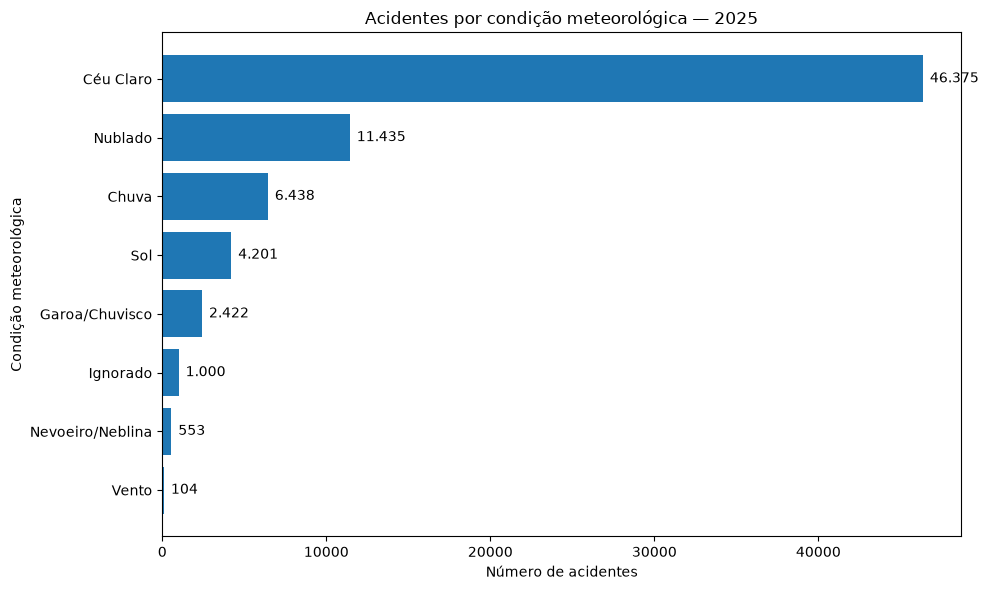

In [265]:
clima_plot = acidentes_clima.head(8).sort_values(
    "acidentes"
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    clima_plot["condicao_metereologica"],
    clima_plot["acidentes"]
)

plt.bar_label(
    bars,
    fmt=lambda x: f"{x:,.0f}".replace(",", "."),
    padding=5
)

plt.title("Acidentes por condição meteorológica — 2025")
plt.xlabel("Número de acidentes")
plt.ylabel("Condição meteorológica")

plt.tight_layout()
plt.show()

### **Análise:** *A maior parte dos acidentes ocorreu sob céu claro: 46.375 ocorrências, equivalentes a 63,9% da base. Em seguida aparecem condições nubladas (11.435) e chuva (6.438). Entretanto, esse resultado não permite concluir que céu claro aumenta o risco de acidentes. Para medir associação com risco seria necessário controlar pela exposição, como quantidade de veículos circulando em cada condição meteorológica.*

### **4.5 — Em quais meses ocorre maior concentração de acidentes?**

In [143]:
df["mes"] = df["data_inversa"].dt.month

acidentes_mes = (
    df.groupby("mes")
      .agg(
          acidentes=("id", "count"),
          mortos=("mortos", "sum"),
          feridos=("feridos", "sum")
      )
      .reset_index()
)

acidentes_mes

,mes,acidentes,mortos,feridos
0,1,5528,418,6915
1,2,5287,412,5974
2,3,5960,462,6784
3,4,5786,495,6678
4,5,6096,574,6834
5,6,6122,528,6920
6,7,6238,536,7129
7,8,6246,554,7006
8,9,6017,500,6876
9,10,6252,494,7231


### *-> Dezembro apresenta a maior quantidade de acidentes: 6.788.*
### *-> Fevereiro apresenta a menor: 5.287*

#### Gráfico - Acidentes por mês

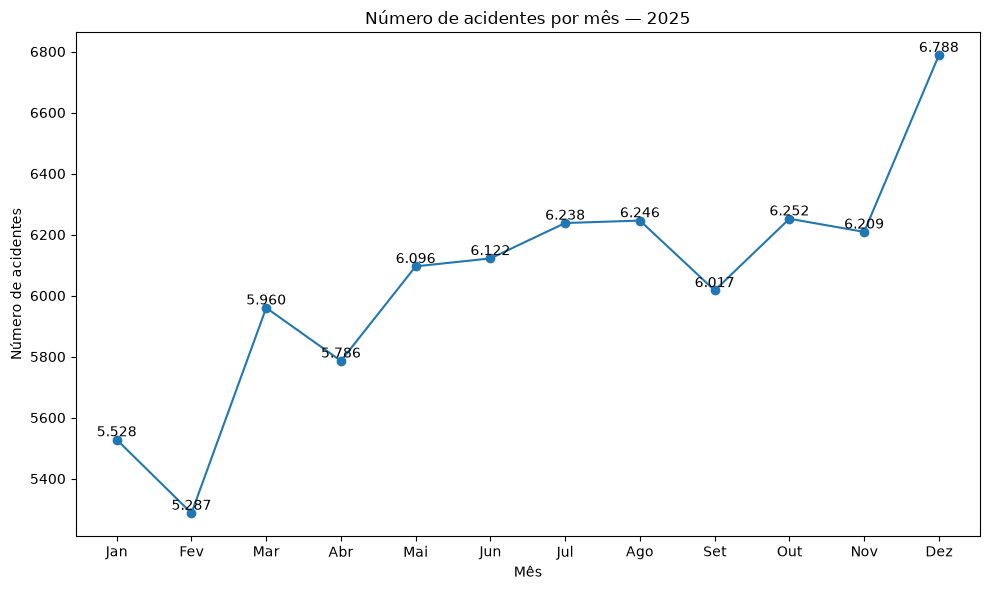

In [267]:
meses = [
    "Jan", "Fev", "Mar", "Abr",
    "Mai", "Jun", "Jul", "Ago",
    "Set", "Out", "Nov", "Dez"
]

plt.figure(figsize=(10, 6))

plt.plot(
    meses,
    acidentes_mes["acidentes"],
    marker="o"
)

for x, y in zip(meses, acidentes_mes["acidentes"]):
    plt.text(
        x,
        y,
        f"{y:,.0f}".replace(",", "."),
        ha="center",
        va="bottom"
    )
    
plt.title("Número de acidentes por mês — 2025")
plt.xlabel("Mês")
plt.ylabel("Número de acidentes")

plt.tight_layout()
plt.show()

### **Análise:** *A quantidade de acidentes apresenta tendência de crescimento ao longo do segundo semestre, atingindo o maior valor em dezembro, com 6.788 ocorrências. O menor volume foi registrado em fevereiro, com 5.287. A diferença entre os dois meses é de 1.501 acidentes, aproximadamente 28,4% a mais em dezembro.*

#### **Pivot_table — Mês × Fase do dia**

In [145]:
tabela_mes_periodo = pd.pivot_table(
    df,
    index="mes",
    columns="fase_dia",
    values="id",
    aggfunc="count",
    fill_value=0
)

tabela_mes_periodo

fase_dia,Amanhecer,Anoitecer,Plena Noite,Pleno dia
mes,,,,
1,241,291,1581,3415
2,246,271,1675,3095
3,283,305,1990,3382
4,262,297,2093,3134
5,317,381,2203,3195
6,344,370,2311,3097
7,347,367,2243,3281
8,307,377,2286,3276
9,250,322,2042,3403


#### Gráfico - Acidentes por mês X Fase do dia

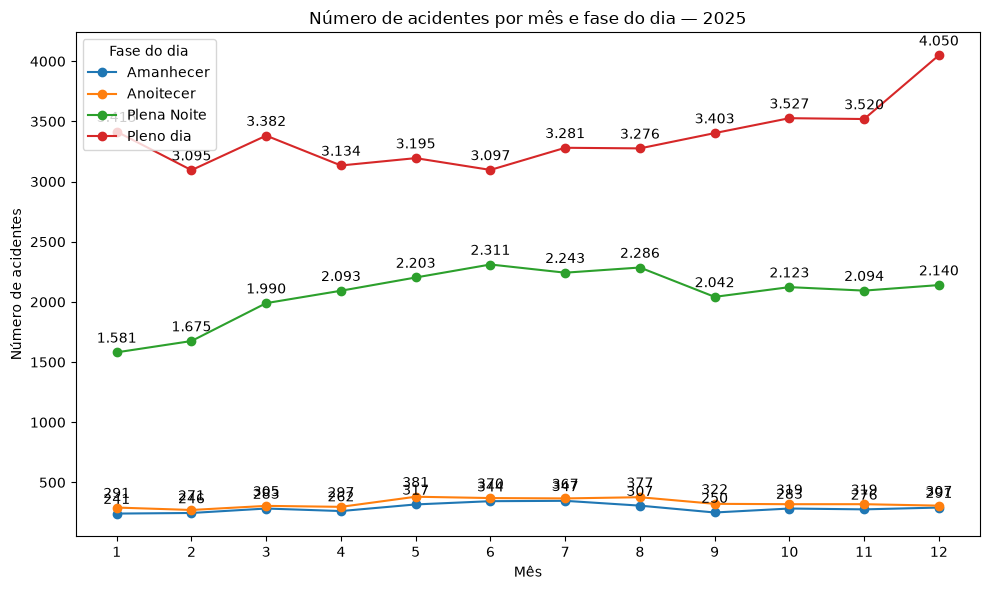

In [268]:
plt.figure(figsize=(10, 6))

for fase in tabela_mes_periodo.columns:

    valores = tabela_mes_periodo[fase]

    plt.plot(
        tabela_mes_periodo.index,
        valores,
        marker="o",
        label=fase
    )

    for x, y in zip(tabela_mes_periodo.index, valores):
        plt.annotate(
            f"{y:,.0f}".replace(",", "."),
            (x, y),
            textcoords="offset points",
            xytext=(0, 7),
            ha="center"
        )

plt.title("Número de acidentes por mês e fase do dia — 2025")
plt.xlabel("Mês")
plt.ylabel("Número de acidentes")
plt.xticks(range(1, 13))
plt.legend(title="Fase do dia")

plt.tight_layout()
plt.show()

# **EXTRAS**

### **4.6 Em quais períodos do dia ocorre maior concentração de acidentes?**

In [146]:
acidentes_periodo = (
    df.groupby("fase_dia")
      .agg(
          acidentes=("id", "count"),
          mortos=("mortos", "sum"),
          feridos=("feridos", "sum")
      )
      .reset_index()
      .sort_values("acidentes", ascending=False)
)

acidentes_periodo

,fase_dia,acidentes,mortos,feridos
3,Pleno dia,40375,2391,48052
2,Plena Noite,24781,2892,27179
1,Anoitecer,3926,288,4558
0,Amanhecer,3447,472,3761


### **Análise** *Embora o Pleno dia tenha muito mais acidentes, a Plena Noite teve mais mortes:* *Pleno dia → 2.391 mortes* | *Plena Noite → 2.892 mortes*. *Isso sugere que frequência e gravidade não são necessariamente a mesma coisa.*

In [147]:
tabela_dia_semana = pd.pivot_table(
    df,
    index="dia_semana",
    columns="fase_dia",
    values="id",
    aggfunc="count",
    fill_value=0
)

tabela_dia_semana

fase_dia,Amanhecer,Anoitecer,Plena Noite,Pleno dia
dia_semana,,,,
domingo,631,633,4832,5374
quarta-feira,389,573,2912,5682
quinta-feira,422,501,2973,5509
segunda-feira,518,573,2942,6252
sexta-feira,493,634,3829,6241
sábado,602,467,4710,5775
terça-feira,392,545,2583,5542


### **Análise** *Em relação aos acidentes com vitimas fatais(mortes), que ocorrem principalmente em "Plena Noite", foi constatado maior incidência nos dias da semana Domingo, Sábado e Sexta Feira.*

# Etapa 5: Conclusões

## **5.1 Principais achados**

1.  A maior parte dos acidentes registrados ocorreu em condições e situações que envolvem o comportamento dos condutores, com destaque para causas como ausência de reação do condutor e reação tardia ou ineficiente. Esse resultado reforça a importância de ações preventivas voltadas à atenção e ao comportamento na condução.
2.  Os acidentes apresentam concentração diferente entre os estados, com destaque para Minas Gerais, Santa Catarina e Paraná em número de registros. Essa distribuição pode auxiliar no direcionamento de ações de fiscalização, prevenção e educação no trânsito.
3.  A ocorrência de acidentes varia ao longo do ano e entre os dias da semana, indicando que períodos específicos podem concentrar maior quantidade de registros. Essa informação pode contribuir para o planejamento de ações preventivas e de fiscalização em períodos de maior ocorrência.
4.  A gravidade dos acidentes é heterogênea, havendo registros sem vítimas, com vítimas feridas e com vítimas fatais. Portanto, a quantidade de acidentes, isoladamente, não representa o impacto desses eventos sobre as pessoas.

## **5.2 Limitações da análise**

Os dados permitem identificar padrões e características dos acidentes registrados nas rodovias federais em 2025, mas não permitem afirmar, isoladamente, que determinado fator causou os acidentes. Também não é possível concluir que um estado ou período é necessariamente mais perigoso apenas pela quantidade de registros, pois seria necessário considerar fatores como fluxo de veículos, extensão da malha rodoviária e exposição ao risco.

## **5.3 Próximos passos**

Com mais tempo e dados complementares, seria interessante aprofundar a análise de algumas situações específicas. Um exemplo é o registro de acidentes associado à condição meteorológica “neve”, que merece ser investigado para verificar a consistência desses registros, sua localização, período de ocorrência e possível relação com outras variáveis da base. Também seria interessante cruzar os acidentes com dados de fluxo de veículos, características das rodovias e condições meteorológicas externas, permitindo uma avaliação mais completa dos fatores associados aos acidentes.